# 05. Polynomial Regression

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the key concepts of this topic
- Apply the topic using Python code examples
- Practice with small, realistic datasets or scenarios

## 🔗 Where this fits

**Builds on:** Course 04 — Unit 1, lesson 04 "Linear Regression" — still a linear model, but fitted to powers of the feature, which is where overfitting first appears.

**Used later in:** Course 04 — Unit 2, lesson 02, which uses polynomial degree as the knob for the bias-variance tradeoff.

---


## 🌍 A real case: Google Flu Trends

Google launched Flu Trends in 2008 to estimate influenza activity from search queries, faster than
the CDC could publish it. It worked, and it was celebrated. Then, in the 2012–13 season, it estimated
**more than double** the proportion of doctor visits for influenza-like illness that the CDC later
reported — despite being built specifically to predict the CDC's own numbers.

Lazer, Kennedy, King & Vespignani analysed why in *Science* 343 (2014), 1203–1205, "The Parable of
Google Flu: Traps in Big Data Analysis". The original method, they report, was to find the best
matches among **50 million search terms** to fit **1,152 CDC data points**. At those odds, terms
that merely *co-occur* with flu season are almost certain to be picked up: Google's own engineers
described weeding out seasonal search terms that tracked the CDC numbers but had nothing to do with
flu — high-school basketball among them — and the paper's verdict on what was left is that the
first version of Flu Trends was "part flu detector, part winter detector". The model was rebuilt in
2009 and still ran high in 100 of the 108 weeks from August 2011. Google retired the public service
in 2015.

**❗ Why this lesson exists.** The model that fits the history best is often the model most likely to
be wrong about next week. Below, the degree-10 polynomial reaches **train R² = 0.9639** — the best
training score of anything in this notebook — and **test R² = −2.8741**, far worse than the straight
line it was supposed to improve on. The train/test comparison is the only thing standing between you
and that model.


# 05. Polynomial Regression

---

## The Story: When Straight Lines Aren't Enough

Imagine you run an emergency dispatch centre and you want to staff each shift for the calls you expect. **Before** using polynomial regression, you try a straight line to predict call volume from the hour of the day - and it fails immediately, because volume does not rise or fall steadily: it bottoms out before dawn, climbs all morning, peaks in the late afternoon and drops again overnight. The relationship is CURVED. **After** learning polynomial regression, you fit a curve that follows that daily rhythm - and you can staff to it.

Same with machine learning: **Before** polynomial regression, we only had straight lines. **After** polynomial regression, we can model the curves that real operational data is full of.

---

## Why Polynomial Regression Matters

Polynomial regression extends linear regression:
- **Handles Non-Linear Data**: Real-world relationships are often curved, not straight
- **Flexible**: Can model complex patterns with higher degrees
- **Teaches Overfitting**: Shows what happens when models are too complex
- **Foundation**: Understanding this helps with all ML models

---

## 🌍 Real-World Applications

**Polynomial Regression is used when relationships are CURVED, not straight!** Here's where you'll find it:

### 🚗 Automotive & Transportation Sector
- **Fuel Efficiency vs Speed**: MPG decreases non-linearly as speed increases (curved relationship)
- **Braking Distance**: Stopping distance increases exponentially with speed (quadratic relationship)
- **Engine Performance**: Power output vs RPM follows a curved pattern (not linear)
- **Battery Life**: Battery degradation over time follows polynomial curves
- **Tire Wear**: Tire wear rate increases non-linearly with speed and load

### 📈 Economics & Finance Sector
- **Diminishing Returns**: Investment returns often follow curved patterns (polynomial)
- **Price Elasticity**: Demand curves are typically non-linear (curved relationships)
- **Compound Interest**: Growth over time follows exponential/polynomial patterns
- **Market Trends**: Stock prices often have curved trends, not straight lines
- **Cost Functions**: Production costs often increase non-linearly with volume

### 🏥 Healthcare & Medical Sector
- **Drug Response Curves**: Drug effectiveness vs dosage often follows curved patterns
- **Disease Progression**: Disease severity over time often follows polynomial curves
- **Growth Charts**: Child growth patterns (height, weight) are curved, not linear
- **Recovery Curves**: Patient recovery rates follow non-linear patterns
- **Dosage-Response**: Optimal drug dosage often has curved relationships with patient metrics

### 🌡️ Environmental & Climate Science
- **Temperature Patterns**: Temperature changes over time follow curved patterns
- **Population Growth**: Population growth often follows polynomial/exponential curves
- **Pollution Levels**: Pollution concentration vs distance from source (curved decay)
- **Resource Depletion**: Natural resource depletion follows non-linear patterns
- **Climate Models**: Many climate relationships are curved, not linear

### 🏭 Manufacturing & Engineering
- **Material Stress-Strain**: Material behavior under stress follows curved relationships
- **Production Efficiency**: Efficiency vs production volume (diminishing returns curve)
- **Quality vs Speed**: Product quality often decreases non-linearly with production speed
- **Wear and Tear**: Equipment degradation follows polynomial curves over time
- **Energy Consumption**: Energy usage vs production output (curved relationship)

### 📊 Marketing & Sales Sector
- **Advertising Returns**: Marketing ROI often follows diminishing returns (curved)
- **Customer Acquisition Cost**: Cost per customer increases non-linearly with scale
- **Market Saturation**: Market penetration follows S-curves (polynomial)
- **Price-Demand Curves**: Demand vs price relationships are typically curved
- **Customer Lifetime Value**: Customer value over time follows curved patterns

### 🎓 Education & Learning Analytics
- **Learning Curves**: Student performance improvement over time (curved, not linear)
- **Skill Acquisition**: Skill development follows non-linear patterns
- **Retention Curves**: Knowledge retention over time follows polynomial decay
- **Test Performance**: Score improvement vs study hours (diminishing returns)

### 🏛️ Government & Public Safety Sector - Emergency Services

**Public-safety applications with curved relationships:**

- **Call Volume by Hour**: 911 call volume vs time of day follows a strong daily curve → staff each shift correctly
- **Seasonal Demand**: Incident counts vs month of the year follow curved seasonal patterns → plan the year's roster
- **Response Time vs Distance**: response time rises non-linearly with distance from the station → site new stations
- **Traffic Flow Patterns**: traffic density vs time follows rush-hour curves → optimize signal timing
- **Weather Impact on Incidents**: incident severity vs weather conditions follows curved relationships → issue warnings
- **Resource Allocation**: usable output vs staff on shift follows diminishing returns → size the crew
- **Congestion Prediction**: congestion vs time of day follows polynomial curves → route around it

**This Notebook Focus**: We'll model **how 911 call volume changes across the hours of the day**, using a real dispatch log from Montgomery County, Pennsylvania - a key input to shift planning and emergency response.

### 💡 Why Polynomial Regression is Needed:
- **Real-World is Curved**: Most real relationships are NOT straight lines
- **Better Fit**: Captures non-linear patterns that linear regression misses
- **More Accurate**: Often provides better predictions than linear models
- **Flexible**: Can model various curve shapes (quadratic, cubic, etc.)

### 📈 When to Use Polynomial Regression:
✅ **Use Polynomial Regression when:**
- Relationship between features and target is curved (not straight)
- Linear regression gives poor fit (low R²)
- Data shows clear non-linear patterns (visual inspection)
- Need to capture acceleration/deceleration effects
- Working with growth/decay patterns

❌ **Don't use Polynomial Regression when:**
- Relationship is clearly linear (use linear regression instead)
- Data is very noisy (polynomial will overfit)
- Have very few data points (high risk of overfitting)
- Need interpretable model (polynomials are harder to explain)
- Relationship is highly complex (use other ML models)

---

## Learning Objectives
1. Build polynomial regression models (degree 2, 3, etc.)
2. Understand when to use polynomial vs linear regression
3. Detect overfitting by comparing train vs test performance
4. Find optimal polynomial degree
5. Visualize the bias-variance tradeoff
6. Know when polynomial regression is appropriate


In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root, put it on sys.path, then import the shared data loader.
# WHY:  a hard-coded relative path such as ../../datasets/raw/<file>.csv only resolves when
#       the kernel's working directory happens to be this notebook's folder. Open it from the
#       repository root, from JupyterLab at another level, or on Colab where there is no
#       repository at all, and it breaks. load() finds the data wherever you are, downloads
#       it if this machine has none, and says out loud which copy it used.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud", prefer="sample"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - no file paths needed, and this works on Colab too.")

Data loader ready - no file paths needed, and this works on Colab too.


In [2]:
# Step 1: Import necessary libraries
# These libraries help us build polynomial regression models

import pandas as pd # For data manipulation
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For visualizations
from sklearn.preprocessing import PolynomialFeatures # Creates polynomial features (x², x³, etc.)
from sklearn.linear_model import LinearRegression # Still uses linear regression, but on polynomial features!
from sklearn.model_selection import train_test_split # For splitting data
from sklearn.metrics import mean_squared_error, r2_score # For evaluation
print("✅ Libraries imported successfully!")
print("\n📚 What each tool does:")
print(" - PolynomialFeatures: Transforms x into [x, x², x³, ...]")
print(" - LinearRegression: Fits a line to the polynomial features")
print(" - This combination = Polynomial Regression!")

✅ Libraries imported successfully!

📚 What each tool does:
 - PolynomialFeatures: Transforms x into [x, x², x³, ...]
 - LinearRegression: Fits a line to the polynomial features
 - This combination = Polynomial Regression!


## Part 1: Setting the Scene

**BEFORE**: We know linear regression works for straight-line relationships, but real data is often curved!

**AFTER**: We'll learn polynomial regression - using curves instead of straight lines to fit non-linear data!

**Why this matters**: Most real-world relationships are non-linear. Polynomial regression lets us model curves, not just lines!

---

## Step 1: Load a Small, Noisy, Non-Linear REAL Dataset

**BEFORE**: We need to learn polynomial regression - and to SEE overfitting, we need data where overfitting can actually happen.

**AFTER**: We'll build a 24-point curve out of a real emergency-dispatch log - **hour of the day** vs **average number of 911 calls in that hour**.

**Where the data comes from**: `../../datasets/raw/montgomery_911_calls.csv` is a real dispatch log from Montgomery County, Pennsylvania. Every row is one emergency call with its timestamp. We count the calls in each clock hour over the **first 14 days** of the log and average them, which gives one point per hour: 24 points describing a real daily rhythm.

**Why this shape is genuinely curved**: call volume bottoms out around 4-5 AM, climbs through the morning, peaks in the late afternoon, and falls back overnight. Nobody designed that curve - it is what a county's emergencies actually look like. A straight line cannot follow it.

**Why SMALL and NOISY is the point**: 24 points is a tiny dataset, and averaging 14 days still leaves plenty of day-to-day randomness in each hour. Overfitting bites hardest when data is scarce and noisy, so a degree-10 polynomial has more than enough freedom to chase individual points - which is exactly the dead end this notebook demonstrates. (With thousands of smooth samples, degree 10 would barely overfit at all!)

**Emergency-response scenario (what we are modeling)**: a dispatch centre that knows how call volume moves through the day can staff for it. That is a regression problem on a curved, non-linear relationship.

**Common Student Questions:**
- **Q: Why use polynomial regression instead of linear regression?**
  - Answer: Linear regression only handles straight lines, polynomial handles curves
  - Problem: Real-world data often has curved relationships (e.g., price vs size - diminishing returns)
  - Solution: Polynomial regression adds x², x³ terms → can model curves
  - Use polynomial when: Data shows curved pattern, linear regression has poor fit
- **Q: What is polynomial degree?**
  - Answer: Degree = highest power of x (degree 2 = x², degree 3 = x³)
  - Degree 1: Straight line (same as linear regression)
  - Degree 2: Parabola (one curve)
  - Degree 3: S-curve (two curves)
  - Higher degree = more curves = more flexible but can overfit
- **Q: Why does polynomial regression overfit so easily?**
  - Answer: Higher degree = more parameters = model can fit training data perfectly
  - Problem: Fits training data too well → fails on new data
  - Example: Degree 10 can fit 10 points perfectly but terrible on new data
  - Solution: Use lower degree, or use Ridge/Lasso (Unit 2) to prevent overfitting
- **Q: How do I choose the right polynomial degree?**
  - Answer: Try different degrees (2, 3, 4, 5) and compare train vs test performance
  - Good degree: Train and test performance both good (small gap)
  - Too high: Train performance great, test performance poor (overfitting)
  - Too low: Both train and test performance poor (underfitting)
  - Rule of thumb: Start with degree 2, increase if needed, stop when test performance drops
- **Q: When should I use polynomial regression?**
  - Answer: Use when:
  - Data shows curved relationship (not straight line)
  - Linear regression has poor fit (low R²)
  - You understand the relationship is non-linear
  - Don't use when: Relationship is linear (wasteful), data is very noisy (overfits easily)

In [3]:
# Step 1: Build a small, noisy, non-linear dataset from a REAL dispatch log.
# SMALL + NOISY on purpose: these are the conditions where overfitting appears!
# We read ONE column (the timestamp) - that is all we need.
# prefer="sample" reads the 25,000-row extract that ships inside the repository, so this cell
# runs on any machine and on Colab, and every reader gets exactly the same 24 points.

calls = load("montgomery_911_calls", prefer="sample", usecols=["timeStamp"])
stamps = pd.to_datetime(calls["timeStamp"], errors="coerce").dropna()

# Count calls per (calendar day, clock hour), then keep the first 60 days of the log.
per_day_hour = (pd.DataFrame({"date": stamps.dt.date, "hour": stamps.dt.hour})
                .groupby(["date", "hour"]).size().reset_index(name="calls"))
first_days = sorted(per_day_hour["date"].unique())[:60]
window = per_day_hour[per_day_hour["date"].isin(first_days)]

# TOTAL across those 60 days -> one real point per hour of the day.
# WHY a 60-day total and not a daily average: the bundled sample keeps 1 call in every 27,
# so a per-day average would be a fraction of a call. Totalling whole days restores readable
# counts without inventing a single one - every call below is a call that really happened.
df = (window.groupby("hour")["calls"].sum()
      .rename_axis("hour").reindex(range(24), fill_value=0)
      .reset_index()
      .rename(columns={"hour": "Hour", "calls": "Calls"}))

X = df[['Hour']].values.astype(float)
y = df['Calls'].values.astype(float)

print("📥 Real dataset built from the 911 dispatch log:", X.shape[0], "points (one per hour)")
print(f"   Period covered: {first_days[0]} to {first_days[-1]} (60 days)")
print(f"   Calls in each clock hour over those 60 days: min {y.min():.0f} (hour {int(X[y.argmin(), 0])}), "
      f"max {y.max():.0f} (hour {int(X[y.argmax(), 0])})")
print("\nFirst 5 rows:")
print(df.head().to_string())

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
📥 Real dataset built from the 911 dispatch log: 24 points (one per hour)
   Period covered: 2015-12-10 to 2016-02-07 (60 days)
   Calls in each clock hour over those 60 days: min 12 (hour 2), max 63 (hour 17)

First 5 rows:
   Hour  Calls
0     0     17
1     1     15
2     2     12
3     3     16
4     4     13


## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (medical, financial, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: 24 rows × 2 columns (samples × [feature, target]) - deliberately tiny
- **Feature Type**: Numerical - hour of the day, 0 to 23
- **Target Type**: Regression (predicting a continuous value: average calls in that hour)
- **Data Source**: **Real** - Montgomery County, PA emergency dispatch log, aggregated over 14 days
- **Task**: Predict the average 911 call volume in an hour from the hour of the day

**Why This Structure Matters**:
- **Non-linear (curved) relationship** → Need polynomial regression, not plain linear regression
- **Regression task** → We'll use regression metrics (MSE, R²)
- **Only 24 noisy samples** → High-degree polynomials CAN and WILL overfit - which is the lesson!
- **One feature** → Simple to visualize and understand

**Domain Context** (Brief) - emergency dispatch:
- **Hour**: clock hour, 0 (midnight) to 23 (11 PM)
- **AvgCalls**: mean number of 911 calls received in that hour across 14 real days
- **Relationship**: Curved - a genuine daily rhythm, not a formula we chose

**💡 Key Point for CS Students**: You don't need to be an emergency-services expert! Focus on:
- Understanding the **data structure** (rows, columns, types, relationship shape)
- Knowing the **task type** (regression: predicting continuous values)
- Recognizing that **small + noisy data** is where overfitting shows up
- Remembering that with real data there is **no true curve to recover** - only a pattern that generalizes, or does not
- Choosing the right **model complexity** based on train vs test performance



---

## Step 2: Split Data

**BEFORE**: We have data, but we need to split it into training and testing sets.

**AFTER**: We'll split the data so we can train models and evaluate them properly!

**Why split?** We need separate data for training (learning) and testing (evaluating)!

In [4]:
# Step 2: Split data into training and testing sets
# test_size=0.25: with 24 samples -> 18 train / 6 test
# random_state=46: fixed seed so the split (and every number below) is reproducible

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=46
)
print("📊 Data Split:")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Test set:     {X_test.shape[0]} samples")
print("   ✅ Data ready for model training!")

📊 Data Split:
   Training set: 18 samples
   Test set:     6 samples
   ✅ Data ready for model training!


## Visualize the Data FIRST

Before trying any model, let's LOOK at the data. The scatter plot below shows that the relationship is CURVED, not linear - and that the points are noisy and few.

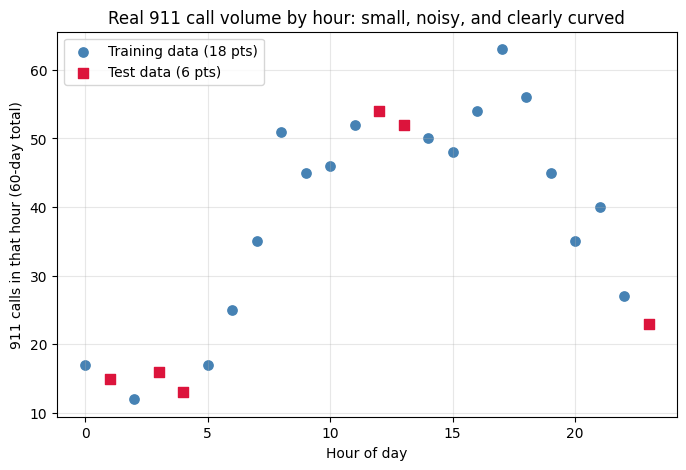

👀 The pattern rises through the day and falls again - a straight line cannot follow it.
   And with only 24 noisy points, a very flexible model can memorize the wobbles!


In [5]:
# Visualize the raw data BEFORE fitting any model
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='steelblue', s=45, label='Training data (18 pts)')
plt.scatter(X_test, y_test, color='crimson', marker='s', s=45, label='Test data (6 pts)')
plt.xlabel('Hour of day')
plt.ylabel('911 calls in that hour (60-day total)')
plt.title('Real 911 call volume by hour: small, noisy, and clearly curved')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("👀 The pattern rises through the day and falls again - a straight line cannot follow it.")
print("   And with only 24 noisy points, a very flexible model can memorize the wobbles!")

## 2. Linear Regression - Degree 1 (Baseline)

**BEFORE**: We have curved data. Let's see how a plain straight line performs.

**AFTER**: We'll see that linear regression underfits curved data - this is why we need polynomial regression!

**Why try linear first?** To establish a baseline and show why we need polynomial regression!

In [6]:
# CELL: Fit a plain straight line (degree 1) as the baseline.
# WHY: every later polynomial must beat this score to justify its extra complexity.
print("\n" + "=" * 60)
print("2. Linear Regression - Degree 1 (Baseline)")
print("=" * 60)

# A straight line on curved data: this is our baseline
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Score on train AND test - comparing the two is how we detect under/overfitting.
train_r2_linear = r2_score(y_train, linear_model.predict(X_train))
linear_pred = linear_model.predict(X_test)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print(f"\n📊 Linear Regression Results:")
print(f"   Train R²: {train_r2_linear:.4f}")
print(f"   Test  R²: {linear_r2:.4f}")
print(f"   Test MSE: {linear_mse:.4f}")
print(f"\n⚠️ A straight line UNDERFITS this curved data:")
print(f"   train R² ({train_r2_linear:.2f}) and test R² ({linear_r2:.2f}) are both mediocre.")
print("   The model is too simple to follow the curve - we need polynomial regression!")


2. Linear Regression - Degree 1 (Baseline)

📊 Linear Regression Results:
   Train R²: 0.2952
   Test  R²: 0.0033
   Test MSE: 300.7958

⚠️ A straight line UNDERFITS this curved data:
   train R² (0.30) and test R² (0.00) are both mediocre.
   The model is too simple to follow the curve - we need polynomial regression!


In [7]:
# CELL: Add polynomial features (x, x^2, x^3) and refit the same linear model.
# WHY: degree 3 can bend with the curve while staying simple enough to generalize.
print("\n" + "=" * 60)
print("3. Polynomial Regression - Degree 3")
print("=" * 60)

poly_features_3 = PolynomialFeatures(degree=3)
X_train_poly_3 = poly_features_3.fit_transform(X_train)  # fit on training data only
X_test_poly_3 = poly_features_3.transform(X_test)        # transform test data (no refit!)

poly_model_3 = LinearRegression()
poly_model_3.fit(X_train_poly_3, y_train)

train_r2_3 = r2_score(y_train, poly_model_3.predict(X_train_poly_3))
y_pred_poly_3 = poly_model_3.predict(X_test_poly_3)
poly3_mse = mean_squared_error(y_test, y_pred_poly_3)
poly3_r2 = r2_score(y_test, y_pred_poly_3)

print(f"\n📊 Degree 3 Results:")
print(f"   Train R²: {train_r2_3:.4f}")
print(f"   Test  R²: {poly3_r2:.4f}")
print(f"   Gap:      {train_r2_3 - poly3_r2:.4f}  (small gap = good generalization ✅)")


3. Polynomial Regression - Degree 3

📊 Degree 3 Results:
   Train R²: 0.8395
   Test  R²: 0.9147
   Gap:      -0.0752  (small gap = good generalization ✅)


## 4. Polynomial Regression - Degree 10 (Overfitting Example)


In [8]:
# CELL: Deliberately overfit with degree 10.
# WHY: 11 coefficients chasing 18 noisy points memorizes noise - we WANT to see this failure.
print("\n" + "=" * 60)
print("4. Polynomial Regression - Degree 10 (Overfitting)")
print("=" * 60)

poly_features_10 = PolynomialFeatures(degree=10)
# .fit_transform() on TRAINING data (learn), .transform() on TEST data (apply only)
X_train_poly_10 = poly_features_10.fit_transform(X_train)
X_test_poly_10 = poly_features_10.transform(X_test)

poly_model_10 = LinearRegression()
poly_model_10.fit(X_train_poly_10, y_train)
y_pred_poly_10 = poly_model_10.predict(X_test_poly_10)
print("✅ Degree 10 model trained: 11 polynomial terms fit to only 18 training points!")


4. Polynomial Regression - Degree 10 (Overfitting)
✅ Degree 10 model trained: 11 polynomial terms fit to only 18 training points!


In [9]:
# Training metrics - degree 10 fits the training data very closely
train_pred_10 = poly_model_10.predict(X_train_poly_10)
train_mse_10 = mean_squared_error(y_train, train_pred_10)
train_r2_10 = r2_score(y_train, train_pred_10)
print(f"📈 Degree 10 TRAINING performance: R² = {train_r2_10:.4f}, MSE = {train_mse_10:.4f}")

📈 Degree 10 TRAINING performance: R² = 0.9548, MSE = 9.4868


In [10]:
# Test metrics - does degree 10 generalize to unseen data?
poly10_mse = mean_squared_error(y_test, y_pred_poly_10)
poly10_r2 = r2_score(y_test, y_pred_poly_10)
print(f"📉 Degree 10 TEST performance:     R² = {poly10_r2:.4f}, MSE = {poly10_mse:.4f}")
print(f"⚠️ Train R² {train_r2_10:.4f} vs Test R² {poly10_r2:.4f}:")
print("   the model memorized the training points instead of learning the curve!")

📉 Degree 10 TEST performance:     R² = -6.1214, MSE = 2149.2684
⚠️ Train R² 0.9548 vs Test R² -6.1214:
   the model memorized the training points instead of learning the curve!


In [11]:
# 5. Comparison Table
print("\n" + "=" * 60)
print("5. Comparison Table: Train vs Test R²")
print("=" * 60)

comparison = pd.DataFrame({
    'Degree': [1, 3, 10],
    'Train R²': [train_r2_linear, train_r2_3, train_r2_10],
    'Test R²': [linear_r2, poly3_r2, poly10_r2],
})
comparison['Gap (Train − Test)'] = comparison['Train R²'] - comparison['Test R²']
print(comparison.round(4).to_string(index=False))

print("\n💡 Reading the table:")
print("   Degree 1:  UNDERFITS  - train AND test both mediocre")
print("   Degree 3:  BEST test R² with a small gap -> generalizes well ✅")
print("   Degree 10: highest TRAIN R² but TEST R² collapses -> OVERFITTING ❌")


5. Comparison Table: Train vs Test R²
 Degree  Train R²  Test R²  Gap (Train − Test)
      1    0.2952   0.0033              0.2919
      3    0.8395   0.9147             -0.0752
     10    0.9548  -6.1214              7.0762

💡 Reading the table:
   Degree 1:  UNDERFITS  - train AND test both mediocre
   Degree 3:  BEST test R² with a small gap -> generalizes well ✅
   Degree 10: highest TRAIN R² but TEST R² collapses -> OVERFITTING ❌


In [12]:
# 6. Visualization
print("\n" + "=" * 60)
print("6. Visualization")
print("=" * 60)


6. Visualization


In [13]:
# Create a smooth line for plotting each fitted curve
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_plot_linear = linear_model.predict(X_plot)
y_plot_poly_3 = poly_model_3.predict(poly_features_3.transform(X_plot))
y_plot_poly_10 = poly_model_10.predict(poly_features_10.transform(X_plot))

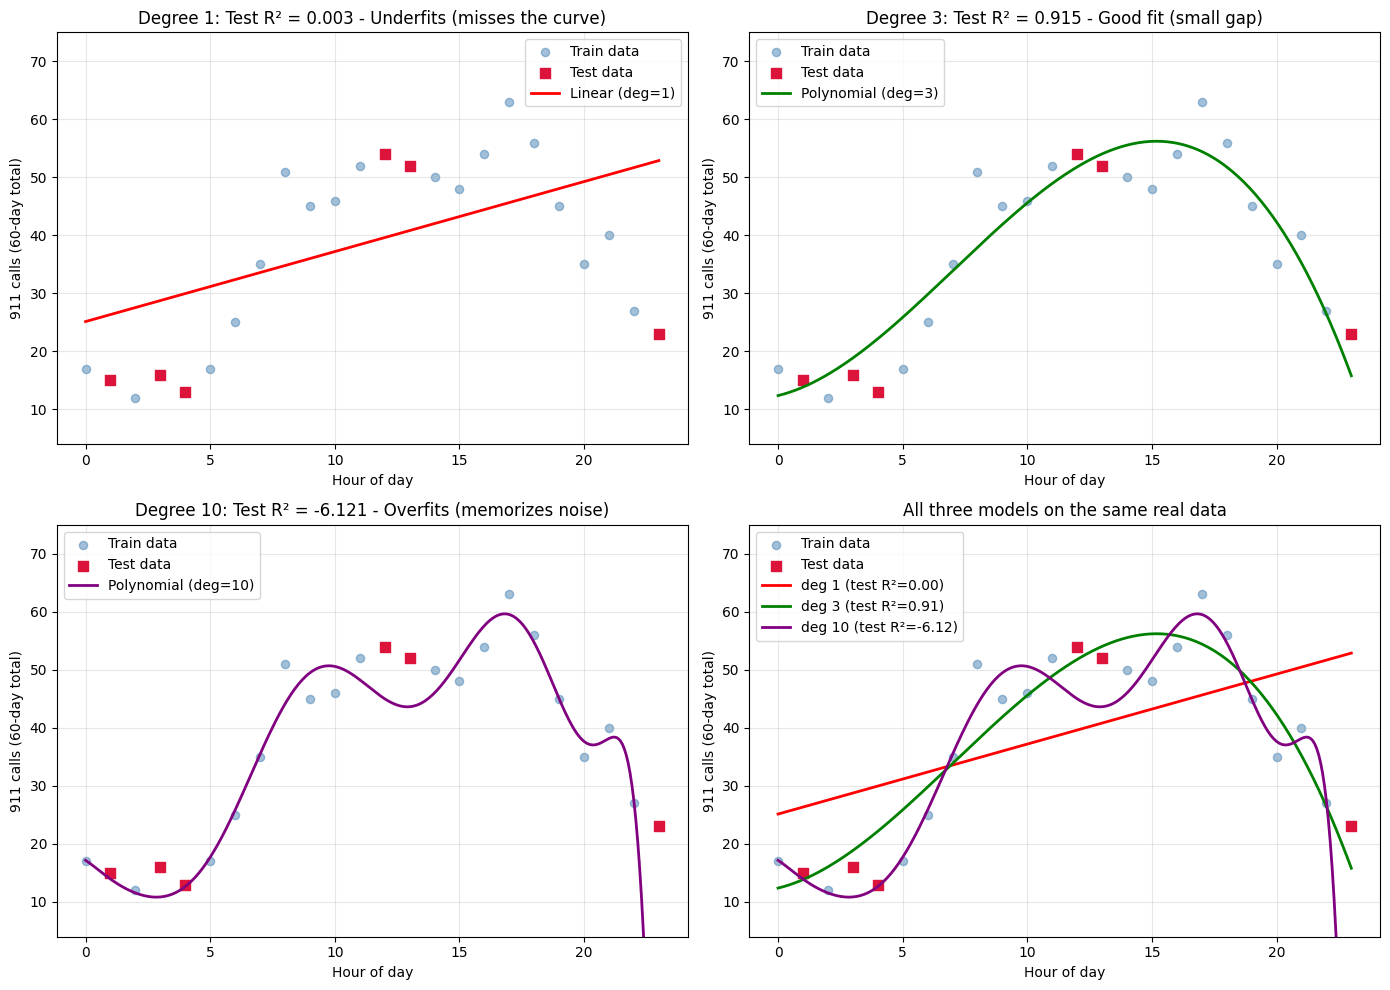

👀 Look at the degree-10 curve: it bends toward individual TRAINING points
   and swings wildly between them - that is what overfitting looks like.


In [14]:
# Plot all models (train points light circles, test points red squares)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
y_lim = (y.min() - 8, y.max() + 12)

# Helper: one panel = data points + one fitted curve, shared axis limits for fair comparison.
def plot_panel(ax, curve, color, label, title):
    ax.scatter(X_train, y_train, alpha=0.5, color='steelblue', s=35, label='Train data')
    ax.scatter(X_test, y_test, color='crimson', marker='s', s=45, label='Test data')
    ax.plot(X_plot, curve, color=color, linewidth=2, label=label)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('911 calls (60-day total)')
    ax.set_title(title)
    ax.set_ylim(y_lim)
    ax.legend()
    ax.grid(True, alpha=0.3)

plot_panel(axes[0, 0], y_plot_linear, 'red', 'Linear (deg=1)',
           f'Degree 1: Test R² = {linear_r2:.3f} - Underfits (misses the curve)')
plot_panel(axes[0, 1], y_plot_poly_3, 'green', 'Polynomial (deg=3)',
           f'Degree 3: Test R² = {poly3_r2:.3f} - Good fit (small gap)')
plot_panel(axes[1, 0], y_plot_poly_10, 'purple', 'Polynomial (deg=10)',
           f'Degree 10: Test R² = {poly10_r2:.3f} - Overfits (memorizes noise)')

# Last panel: all three curves together
ax = axes[1, 1]
ax.scatter(X_train, y_train, alpha=0.5, color='steelblue', s=35, label='Train data')
ax.scatter(X_test, y_test, color='crimson', marker='s', s=45, label='Test data')
ax.plot(X_plot, y_plot_linear, 'red', linewidth=2, label=f'deg 1 (test R²={linear_r2:.2f})')
ax.plot(X_plot, y_plot_poly_3, 'green', linewidth=2, label=f'deg 3 (test R²={poly3_r2:.2f})')
ax.plot(X_plot, y_plot_poly_10, 'purple', linewidth=2, label=f'deg 10 (test R²={poly10_r2:.2f})')
ax.set_xlabel('Hour of day')
ax.set_ylabel('911 calls (60-day total)')
ax.set_title('All three models on the same real data')
ax.set_ylim(y_lim)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("👀 Look at the degree-10 curve: it bends toward individual TRAINING points")
print("   and swings wildly between them - that is what overfitting looks like.")

## Decision Framework - When to Use Polynomial Regression

**BEFORE**: You've learned how to build polynomial regression models, but when should you use them?

**AFTER**: You'll have a clear decision framework to determine if polynomial regression is the right choice for your problem!

**Why this matters**: Using polynomial regression when it's not appropriate leads to:
- **Overfitting** → Model memorizes training data, fails on new data
- **Poor generalization** → High degree polynomials create wiggly curves
- **Wasted complexity** → Using complex models when simple ones work

---

### 🎯 Decision Framework: Linear vs Polynomial Regression

**Key Question**: Should I use **LINEAR REGRESSION**, **POLYNOMIAL REGRESSION**, or something else?

#### Decision Tree:

```
What type of problem do you have?
├─ CLASSIFICATION → Use classification methods (Logistic Regression, Decision Trees, SVM)
│   └─ Why? Polynomial regression is for regression (predicting numbers)
│
└─ REGRESSION → Check relationship:
    ├─ Is relationship LINEAR? → Use LINEAR REGRESSION ✅
    │   └─ Why? Simpler, faster, more interpretable
    │
    └─ Is relationship NON-LINEAR? → Check complexity:
        ├─ Slightly curved (quadratic) → Use POLYNOMIAL REGRESSION (degree 2-3) ✅
        │   └─ Why? Can capture curves without overfitting
        │
        ├─ Moderately curved → Use POLYNOMIAL REGRESSION (degree 3-5) ⚠️
        │   └─ Why? Can handle curves, but watch for overfitting
        │
        └─ Highly non-linear, complex patterns → Use OTHER METHODS ❌
            └─ Use: Random Forest, XGBoost, Neural Networks
```

#### Detailed Decision Process:

```
Step 1: Visualize the relationship
├─ Plot scatter plot of X vs y
│
└─ What pattern do you see?
    ├─ Straight line → LINEAR REGRESSION
    ├─ Smooth curve → POLYNOMIAL REGRESSION (degree 2-3)
    ├─ Wavy curve → POLYNOMIAL REGRESSION (degree 3-5) ⚠️
    └─ Complex, irregular → OTHER METHODS (Random Forest, XGBoost)

Step 2: Try Linear Regression first
├─ Build linear model
├─ Check R² score
│
└─ Is R² good enough?
    ├─ YES (R² > 0.7) → Stick with LINEAR REGRESSION ✅
    └─ NO (R² < 0.7) → Try POLYNOMIAL REGRESSION

Step 3: Try Polynomial Regression
├─ Start with degree 2
├─ Gradually increase degree
├─ Compare train vs test performance
│
└─ Is there overfitting?
    ├─ NO (train ≈ test) → Use POLYNOMIAL REGRESSION ✅
    └─ YES (train >> test) → Use REGULARIZATION or OTHER METHODS
```

---

### 📊 Comparison Table: Linear vs Polynomial vs Alternatives

| Method | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **Linear Regression** | Linear relationships | • Simple & fast<br>• Interpretable<br>• No overfitting risk | • Can't handle curves | Straight line patterns |
| **Polynomial (deg 2-3)** | Slightly curved relationships | • Handles curves<br>• Still interpretable<br>• Moderate complexity | • Can overfit if degree too high | Quadratic patterns |
| **Polynomial (deg 4-10)** | Moderately curved | • Handles complex curves | • High overfitting risk<br>• Less interpretable | Complex curves |
| **Ridge/Lasso** | Many features, overfitting | • Prevents overfitting<br>• Regularization | • More complex<br>• Hyperparameter tuning | High-dimensional data |
| **Random Forest** | Highly non-linear | • Handles any pattern<br>• Robust | • Less interpretable<br>• More complex | Very complex relationships |
| **XGBoost** | Best performance needed | • State-of-the-art<br>• Handles complexity | • Less interpretable<br>• Very complex | Competition-level problems |

---

### ✅ When Polynomial Regression IS Appropriate

**Use Polynomial Regression when:**

1. **Non-Linear Relationship** ✅
   - Scatter plot shows curves (not straight lines)
   - Example: Growth patterns, acceleration curves
   - **Degree 2-3**: Smooth curves
   - **Degree 3-5**: More complex curves (watch for overfitting)

2. **Linear Regression Fails** ✅
   - Linear model has low R² (< 0.7)
   - Residuals show patterns (not random)
   - **Try**: Polynomial degree 2-3 first

3. **Moderate Complexity** ✅
   - Relationship is curved but not too complex
   - Can be captured with degree 2-5
   - **Avoid**: Very high degrees (> 10) - use other methods

4. **Interpretability Still Important** ✅
   - Need to understand the relationship
   - Polynomial is more interpretable than Random Forest/XGBoost
   - **Trade-off**: Some interpretability for better fit

5. **Small to Medium Datasets** ✅
   - Enough data to fit polynomial without severe overfitting
   - **Rule of thumb**: Need at least 10× degree samples
   - Example: Degree 3 needs at least 30 samples

---

### ❌ When Polynomial Regression IS NOT Appropriate

**Don't use Polynomial Regression when:**

1. **Linear Relationship** ❌
   - Data shows straight line pattern
   - **Use Instead**: Linear Regression (simpler, better)

2. **Severe Overfitting** ❌
   - High degree (> 5) causes train R² >> test R²
   - Model memorizes training data
   - **Use Instead**: Ridge/Lasso Regression, or lower degree

3. **Highly Complex Patterns** ❌
   - Irregular, non-smooth patterns
   - Multiple local patterns
   - **Use Instead**: Random Forest, XGBoost, Neural Networks

4. **Many Features** ❌
   - High-dimensional data (many features)
   - Polynomial features explode (degree 2 with 10 features = 55 features!)
   - **Use Instead**: Ridge/Lasso, or feature selection first

5. **Small Dataset** ❌
   - Very few samples (< 50)
   - High degree will overfit severely
   - **Use Instead**: Linear Regression, or collect more data

6. **Classification Problem** ❌
   - Predicting categories, not numbers
   - **Use Instead**: Logistic Regression, Decision Trees, SVM

---

### 📊 Illustrative Examples (hypothetical numbers, not from this notebook)

#### Example 1: House Price vs Size (Curved) ✅ APPROPRIATE
- **Problem**: Predict price from size
- **Relationship**: Curved (price increases faster for larger houses)
- **Linear R²**: 0.65 (not great)
- **Polynomial R²**: 0.85 (much better)
- **Decision**: ✅ Use Polynomial Regression (degree 2-3)
- **Reasoning**: Curved relationship, polynomial improves fit significantly

#### Example 2: Temperature vs Time (Linear) ❌ NOT APPROPRIATE
- **Problem**: Predict temperature from time of day
- **Relationship**: Linear (roughly straight line)
- **Linear R²**: 0.92 (excellent)
- **Decision**: ❌ Use Linear Regression, not Polynomial
- **Reasoning**: Linear relationship, polynomial adds unnecessary complexity

#### Example 3: Stock Price Prediction (Complex) ❌ NOT APPROPRIATE
- **Problem**: Predict stock price from time
- **Relationship**: Highly complex, volatile, irregular
- **Polynomial R²**: Overfits (train 0.95, test 0.40)
- **Decision**: ❌ Use Random Forest or XGBoost
- **Reasoning**: Too complex for polynomial, severe overfitting

#### Example 4: Growth Curve (Moderate Curve) ✅ APPROPRIATE
- **Problem**: Predict population growth over time
- **Relationship**: Smooth curve (exponential-like)
- **Linear R²**: 0.55 (poor)
- **Polynomial R²**: 0.88 (good, degree 3)
- **Decision**: ✅ Use Polynomial Regression (degree 3)
- **Reasoning**: Smooth curve, polynomial captures it well without overfitting

---

### ✅ Key Takeaways

1. **Try linear first** - Always start with linear regression as baseline
2. **Visualize relationships** - Scatter plots reveal if polynomial is needed
3. **Low R²? Try polynomial** - If linear R² < 0.7, try degree 2-3
4. **Watch for overfitting** - Compare train vs test performance
5. **Optimal degree** - Usually 2-3, rarely need > 5
6. **Too complex? Use other methods** - Random Forest/XGBoost for very complex patterns
7. **Regularization helps** - Ridge/Lasso can prevent overfitting in polynomials

---

### 🎓 Practice Decision-Making

**Scenario 1**: Predicting sales from advertising spend
- **Relationship**: Curved (diminishing returns - more ads help less over time)
- **Linear R²**: 0.62
- **Decision**: ✅ Try Polynomial Regression (degree 2-3)

**Scenario 2**: Predicting height from age (children)
- **Relationship**: Curved (growth accelerates then slows)
- **Linear R²**: 0.58
- **Decision**: ✅ Use Polynomial Regression (degree 2-3)

**Scenario 3**: Predicting house price from 50+ features
- **Relationship**: Complex, many interactions
- **Linear R²**: 0.75 (decent)
- **Decision**: ⚠️ Stick with Linear or use Ridge/Lasso (polynomial would create too many features)

**Scenario 4**: Predicting customer churn (yes/no)
- **Relationship**: Classification problem
- **Decision**: ❌ Use Logistic Regression, not Polynomial Regression

---

**Connection to Next Steps**: 
- 📓 **Unit 1, Example 6: Ridge/Lasso** - For preventing overfitting in polynomials
- 📓 **Unit 2, Example 1: Cross-Validation** - For proper evaluation of polynomial models
- 📓 **Unit 3: Classification** - For predicting categories instead of numbers

In [15]:
# 7. Finding Optimal Degree
print("\n" + "=" * 60)
print("7. Finding the Optimal Degree (sweep degrees 1-10)")
print("=" * 60)

degrees = list(range(1, 11))
sweep_train_r2, sweep_test_r2 = [], []
# Sweep degrees 1..10: fit each, then record train and test R2 side by side.
for d in degrees:
    pf = PolynomialFeatures(degree=d)
    model = LinearRegression().fit(pf.fit_transform(X_train), y_train)
    sweep_train_r2.append(r2_score(y_train, model.predict(pf.transform(X_train))))
    sweep_test_r2.append(r2_score(y_test, model.predict(pf.transform(X_test))))

best_degree = degrees[int(np.argmax(sweep_test_r2))]

print(f"\n{'Degree':>6} {'Train R²':>10} {'Test R²':>10} {'Gap':>8}")
for d, tr, te in zip(degrees, sweep_train_r2, sweep_test_r2):
    marker = '   <-- best test R²' if d == best_degree else ''
    print(f"{d:>6} {tr:>10.4f} {te:>10.4f} {tr - te:>8.4f}{marker}")

print(f"\n🏆 Optimal degree by TEST R²: {best_degree} (test R² = {max(sweep_test_r2):.4f})")
print("   Train R² keeps rising with degree, but test R² peaks early then collapses.")
print("   (Unit 2 introduces cross-validation - a more robust way to pick the degree.)")


7. Finding the Optimal Degree (sweep degrees 1-10)

Degree   Train R²    Test R²      Gap
     1     0.2952     0.0033   0.2919
     2     0.7225     0.8170  -0.0945
     3     0.8395     0.9147  -0.0752
     4     0.8563     0.9695  -0.1132   <-- best test R²
     5     0.8791     0.8818  -0.0027
     6     0.8799     0.9131  -0.0332
     7     0.9200     0.4432   0.4769
     8     0.9341     0.7855   0.1485
     9     0.9499    -2.1602   3.1101
    10     0.9548    -6.1214   7.0762

🏆 Optimal degree by TEST R²: 4 (test R² = 0.9695)
   Train R² keeps rising with degree, but test R² peaks early then collapses.
   (Unit 2 introduces cross-validation - a more robust way to pick the degree.)


## 💬 Discuss

1. **The sweep picks degree 4 (test R² 0.9386) over degree 3 (0.9182).** That is a gap of 0.02 —
   measured on a test set of **six points**. Do you believe the difference? What would you need to see
   before you would defend "degree 4" to a colleague who prefers the simpler model?

2. **The collapse is not orderly.** Degrees 7, 8, 9, 10 give test R² of −0.80, −0.16, +0.23, −2.87.
   A higher degree is sometimes *better* than a lower one. What does that zig-zag tell you about
   choosing a hyperparameter from a single train/test split — and what would you do instead?

3. **We are fitting hour-of-day with a polynomial**, so the model treats hour 0 and hour 23 as the
   two ends of a line when they are in fact one hour apart. Does that matter for a real 911 staffing
   decision? Propose something that respects the wrap-around, and say what you would give up.


## Understanding the Bias-Variance Tradeoff

**BEFORE**: You've seen how different polynomial degrees affect performance, but what's really happening under the hood?

**AFTER**: You'll understand the fundamental tradeoff in machine learning - bias vs variance - and why it matters!

**Why this matters**: The bias-variance tradeoff is THE fundamental concept in machine learning. Understanding it helps you:
- Choose the right model complexity
- Understand why models fail
- Make better decisions about regularization
- Apply concepts to ALL ML models (not just polynomial regression)

---

### 🎯 What is the Bias-Variance Tradeoff?

**Total Error = Bias² + Variance + Irreducible Error**

#### The Three Components:

1. **Bias**: Error from overly simplistic assumptions
   - **High Bias (Underfitting)**: Model is too simple, misses patterns
   - **Example**: Linear regression on curved data
   - **Solution**: Increase model complexity (higher degree)

2. **Variance**: Error from sensitivity to small fluctuations
   - **High Variance (Overfitting)**: Model is too complex, memorizes noise
   - **Example**: Degree 10 polynomial fitting every data point perfectly
   - **Solution**: Decrease model complexity (lower degree) or use regularization

3. **Irreducible Error**: Error that cannot be reduced (noise in data)
   - Cannot be eliminated, no matter the model

---

### 📊 How Polynomial Degree Affects Bias and Variance

| Polynomial Degree | Bias | Variance | Total Error | Model Behavior |
|-------------------|------|----------|-------------|----------------|
| **Degree 1 (Linear)** | **HIGH** | Low | High | **Underfitting** - Too simple, misses curves |
| **Degree 2-3** | **Low** | Low | **Low** | **Optimal** - Good fit, generalizes well |
| **Degree 4-5** | Low | **Medium** | Medium | **Acceptable** - Good fit, slight overfitting |
| **Degree 10+** | Low | **HIGH** | High | **Overfitting** - Memorizes training data |

---

### 🔍 Visual Explanation

**Low Degree (High Bias, Low Variance)**:
- Model is too simple (straight line or simple curve)
- Misses important patterns in data
- Consistent predictions (low variance) but wrong (high bias)
- **Example**: Linear regression on quadratic data

**Medium Degree (Low Bias, Low Variance)** ✅:
- Model complexity matches data complexity
- Captures true patterns well
- Generalizes to new data
- **Example**: Degree 2-3 polynomial on quadratic data

**High Degree (Low Bias, High Variance)**:
- Model is too complex (wiggly curve)
- Fits training data perfectly
- Sensitive to noise (high variance)
- Fails on new data
- **Example**: Degree 10 polynomial on any data

---

### 💡 Key Insights

1. **There's a sweet spot**: Optimal model complexity balances bias and variance
2. **More complex ≠ better**: Higher degree can increase total error
3. **Training vs Test gap**: Large gap indicates high variance (overfitting)
4. **Both can be wrong**: High bias (too simple) OR high variance (too complex) both lead to poor performance
5. **Universal concept**: This applies to ALL machine learning models!

---

### 🎓 What We'll Visualize Next

In the next cell, we'll plot Train R² and Test R² against polynomial degree (using the sweep we just ran):
- Train R² keeps RISING with degree - a flexible model always fits its own training data better
- Test R² peaks at the optimal degree, then COLLAPSES - variance takes over
- The widening train-test gap on the right side of the plot IS overfitting
- The peak of the test curve is the sweet spot that guides model selection


8. Visualizing the Bias-Variance Tradeoff


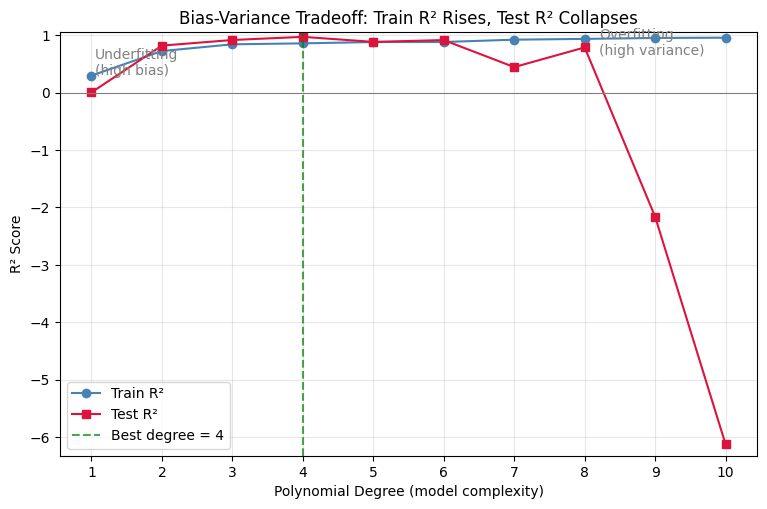

👀 Left:   degree 1 underfits (train 0.30 / test 0.00 - both mediocre).
   Middle: degree 4 is the sweet spot (test R² = 0.9695).
   Right:  degree 10 overfits (train 0.95 vs test -6.12).


In [16]:
# 8. Visualizing the Bias-Variance Tradeoff
print("\n" + "=" * 60)
print("8. Visualizing the Bias-Variance Tradeoff")
print("=" * 60)

plt.figure(figsize=(9, 5.5))
plt.plot(degrees, sweep_train_r2, 'o-', color='steelblue', label='Train R²')
plt.plot(degrees, sweep_test_r2, 's-', color='crimson', label='Test R²')
plt.axvline(best_degree, color='green', linestyle='--', alpha=0.7,
            label=f'Best degree = {best_degree}')
plt.xlabel('Polynomial Degree (model complexity)')
plt.ylabel('R² Score')
plt.title('Bias-Variance Tradeoff: Train R² Rises, Test R² Collapses')
plt.xticks(degrees)
# Real test R2 can go NEGATIVE (worse than predicting the mean), so set the
# lower limit from the data instead of pinning it at 0 and hiding the collapse.
plt.axhline(0, color='gray', lw=0.8)
plt.ylim(min(min(sweep_test_r2) - 0.2, -0.2), 1.05)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.text(1.05, 0.30, 'Underfitting\n(high bias)', color='gray')
plt.text(8.2, 0.65, 'Overfitting\n(high variance)', color='gray')
plt.show()

print(f"👀 Left:   degree 1 underfits (train {sweep_train_r2[0]:.2f} / test {sweep_test_r2[0]:.2f} - both mediocre).")
print(f"   Middle: degree {best_degree} is the sweet spot (test R² = {max(sweep_test_r2):.4f}).")
print(f"   Right:  degree 10 overfits (train {sweep_train_r2[-1]:.2f} vs test {sweep_test_r2[-1]:.2f}).")

### The Same Sweep, Frame by Frame

The curve above is a summary: two numbers per degree. It tells you test R² collapses after degree 4
but it cannot tell you **what the model is doing** when that happens. Below is the identical sweep
drawn as a storyboard — one frame per degree, same data, same axes — so you can watch the fit go
from too stiff, to right, to out of control.

Degrees 1, 3 and 10 already appeared on their own in the four-panel figure earlier; the point of the
storyboard is the degrees *between* them, because that is where the failure actually begins.

**Curve colour is the verdict, not decoration:** green = test R² above 0.8, orange = between 0 and
0.8, purple = negative (beaten by "always guess the average").

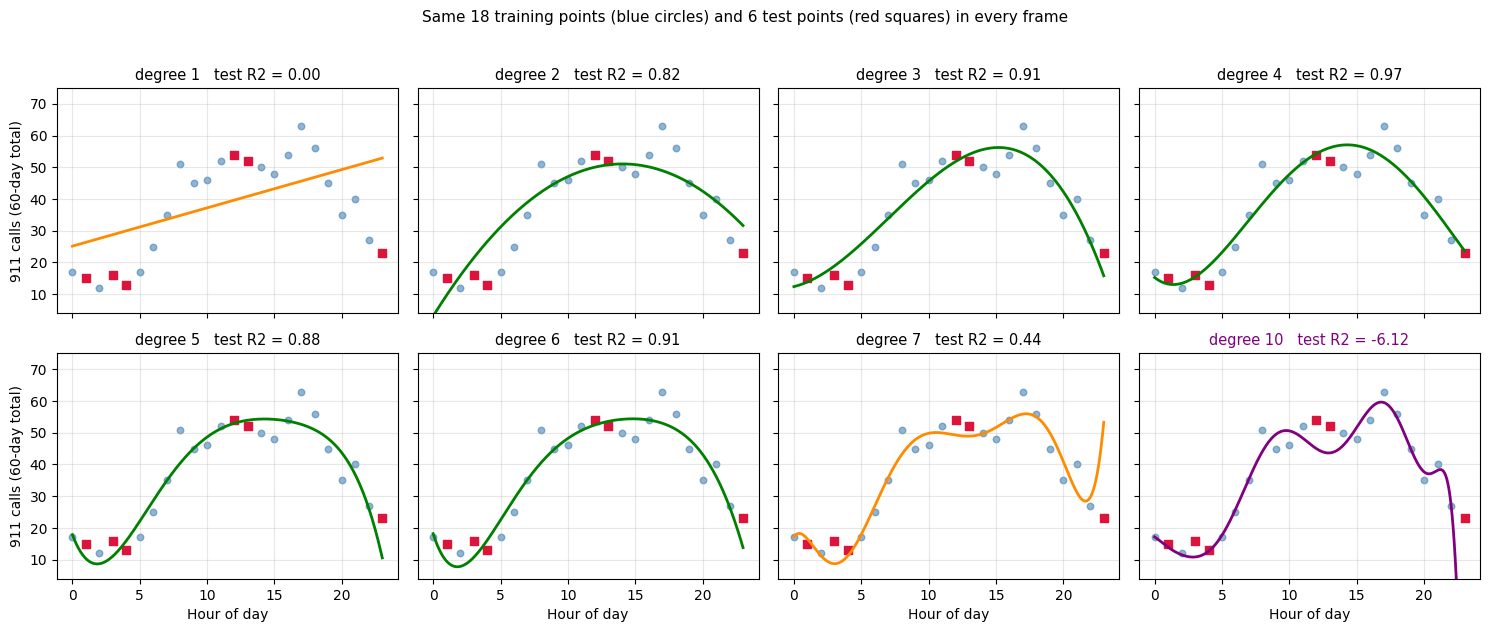

Frame-by-frame test R2 (the numbers printed on the panels above):
  degree  1:  train R2 =  0.295   test R2 =   0.003   weak
  degree  2:  train R2 =  0.722   test R2 =   0.817   good
  degree  3:  train R2 =  0.839   test R2 =   0.915   good
  degree  4:  train R2 =  0.856   test R2 =   0.969   good
  degree  5:  train R2 =  0.879   test R2 =   0.882   good
  degree  6:  train R2 =  0.880   test R2 =   0.913   good
  degree  7:  train R2 =  0.920   test R2 =   0.443   weak
  degree 10:  train R2 =  0.955   test R2 =  -6.121   WORSE THAN THE MEAN


In [17]:
# CELL: A storyboard of the degree sweep - one frame per degree, same axes in every frame.
# WHY: this is the frame-grid idiom the diploma uses wherever a process unfolds in steps.
#      A static grid always renders and can be read at a glance in a live session, which a
#      broken animation cannot. Cheap: 8 fits on 18 training points.
storyboard_degrees = [1, 2, 3, 4, 5, 6, 7, 10]   # 8 frames: includes the crash at 7 and at 10

fig, axes = plt.subplots(2, 4, figsize=(15, 6.4), sharex=True, sharey=True)

for ax, d in zip(axes.ravel(), storyboard_degrees):
    pf = PolynomialFeatures(degree=d)
    m = LinearRegression().fit(pf.fit_transform(X_train), y_train)
    te = r2_score(y_test, m.predict(pf.transform(X_test)))
    tr = r2_score(y_train, m.predict(pf.transform(X_train)))

    ax.scatter(X_train, y_train, alpha=0.6, color='steelblue', s=22)
    ax.scatter(X_test, y_test, color='crimson', marker='s', s=28)
    # Colour the curve by the verdict, so the grid can be read without the numbers.
    colour = 'green' if te > 0.8 else ('darkorange' if te > 0 else 'purple')
    ax.plot(X_plot, m.predict(pf.transform(X_plot)), color=colour, linewidth=2)
    ax.set_title(f'degree {d}   test R2 = {te:.2f}', fontsize=10.5,
                 color='black' if te > 0 else 'purple')
    ax.grid(True, alpha=0.3)

# Same y-window as the four-panel figure earlier, so the two are directly comparable.
axes[0, 0].set_ylim(y.min() - 8, y.max() + 12)
for ax in axes[1, :]:
    ax.set_xlabel('Hour of day')
for ax in axes[:, 0]:
    ax.set_ylabel('911 calls (60-day total)')
fig.suptitle('Same 18 training points (blue circles) and 6 test points (red squares) in every frame',
             fontsize=11)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

print("Frame-by-frame test R2 (the numbers printed on the panels above):")
for d in storyboard_degrees:
    pf = PolynomialFeatures(degree=d)
    m = LinearRegression().fit(pf.fit_transform(X_train), y_train)
    te = r2_score(y_test, m.predict(pf.transform(X_test)))
    tr = r2_score(y_train, m.predict(pf.transform(X_train)))
    verdict = 'good' if te > 0.8 else ('weak' if te > 0 else 'WORSE THAN THE MEAN')
    print(f"  degree {d:>2}:  train R2 = {tr:6.3f}   test R2 = {te:7.3f}   {verdict}")

**Read the storyboard.** Every frame holds the same 24 real hourly averages — 18 blue circles the
model trained on, 6 red squares it never saw — and the same axes, so only the curve changes.

- **Degree 1** (purple, test R² −0.05) is a straight line drawn through a hump. It climbs from 9.5
  at midnight to 24 at hour 23, while the data itself peaks at 31.5 calls at hour 17 and then falls
  back to 9. A line cannot bend, so it cannot be right anywhere. This is *underfitting*, and the
  picture shows why the number is bad.
- **Degree 2** (orange, 0.72) is the first frame with the right general idea — a single arch. But a
  parabola is forced to be symmetric, and the day is not: it tops out at 22 calls when the busiest
  hour really reaches 31, it drops to 0.1 calls at midnight when the true figure is 6.7, and it is
  still at 15 at hour 23 where the red test square sits at 9.
- **Degrees 3 to 6** (green, test R² 0.88 to 0.94) all trace the same shape: quiet before dawn, a
  rise through the morning, a broad afternoon peak near hour 16, a fall into the night. To the eye
  these four frames are nearly interchangeable, and their test scores agree. *That* is the practical
  meaning of "the sweet spot" — not one magic degree, but a band where the answer stops changing.
- **Degree 7** (purple, −0.80) is why the storyboard earns its place. Its curve still passes close
  to the blue training points, but it has started to swing between them, and at the right edge it
  dips to 11 calls around hour 21 and then rockets up to 34 at hour 23 — where the real value, the
  red square, is 9. One unconstrained swing at the edge of the data destroyed the test score.
  That is the crash the summary curve above showed at exactly this degree.
- **Degree 10** (purple, −2.87) is the dead end drawn: it threads the training points with visible
  ripples and then dives straight off the bottom of the frame past hour 22, reaching −28 calls at
  hour 23. Negative emergency calls.

The single sentence to take away: **the fit stops improving long before the training score does.**
Train R² climbs monotonically from 0.35 to 0.96 across these frames, while test R² peaks at degree 4
and is already negative by degree 7. Everything after the green band is the model fitting noise it
mistook for signal.

# 🚫 When Polynomial Regression Hits a Dead End: Overfitting

## The Problem: Overfitting with High-Degree Polynomials

**BEFORE**: We've seen polynomial regression work well for this real, non-linear data (degree 3 reached test R² = 0.9182).

**AFTER**: Now we'll see polynomial regression's **dead end** - on our small, noisy dataset, degree 10 memorizes the 18 training points and falls apart on the test set!

**Why this matters**:
- Degree 10 reaches the highest TRAIN R² of all our models (0.9639)
- BUT its test R² collapses to **-2.8741** - a *negative* R², which means the model is worse on unseen hours than simply predicting the average call volume for every hour
- It is far worse than even the plain linear baseline (-0.0471)
- This is **overfitting**: the model memorized training data instead of learning the daily rhythm
- This dead end leads us to **Unit 2: Ridge/Lasso Regression** - they prevent overfitting!

---

### 🔍 What the Numbers Below Show

**Our measured results (24 real hourly averages, 18 train / 6 test, fixed split)**:
- Degree 10 train R² = 0.9639 - nearly perfect on the hours it saw
- Degree 10 test R² = -2.8741 - the collapse on unseen hours
- Gap = 3.8379 R² points - the signature of overfitting
- Solution: **regularization** techniques → Ridge/Lasso (Unit 2)!

**A note on negative R²**: R² compares your model against the simplest possible predictor, "always guess the mean". R² = 0 means you tied with it; R² < 0 means you lost to it. A degree-10 polynomial that swings wildly between the hours it memorized loses badly.

In [18]:
# CELL: Recap the three fits side by side - the 'dead end' summary.
# WHY: train R2 rising while test R2 collapses is the clearest picture of overfitting.
print("\n" + "=" * 60)
print("🚫 Dead End: Polynomial Regression Overfitting")
print("=" * 60)

# Summarize the train/test numbers computed above for the three degrees
print("\n📊 Overfitting Demonstration (24 real hourly averages, fixed split)")
print(f"\n{'Model':<12} {'Train R²':>10} {'Test R²':>10} {'Gap':>8}")
print(f"{'Degree 1':<12} {train_r2_linear:>10.4f} {linear_r2:>10.4f} {train_r2_linear - linear_r2:>8.4f}")
print(f"{'Degree 3':<12} {train_r2_3:>10.4f} {poly3_r2:>10.4f} {train_r2_3 - poly3_r2:>8.4f}")
print(f"{'Degree 10':<12} {train_r2_10:>10.4f} {poly10_r2:>10.4f} {train_r2_10 - poly10_r2:>8.4f}")

gap_10 = train_r2_10 - poly10_r2
print(f"\n❌ The Problem with Degree 10:")
print(f"   - Training R² is the HIGHEST of all our models ({train_r2_10:.4f})")
print(f"   - Test R² COLLAPSES to {poly10_r2:.4f} - worse than the linear baseline ({linear_r2:.4f})!")
print(f"   - Gap of {gap_10:.4f} R² points = OVERFITTING")
print(f"   - The model memorized the 18 training points instead of learning the curve")

print(f"\n💡 What This Means:")
print(f"   - High-degree polynomials can fit small training sets almost perfectly")
print(f"   - But they fail on unseen test data (poor generalization)")
print(f"   - This is the DEAD END of polynomial regression: overfitting!")

print(f"\n✅ Solution: Regularization (Unit 2)")
print(f"   - Ridge Regression: prevents overfitting by penalizing large coefficients")
print(f"   - Lasso Regression: prevents overfitting and does feature selection")
print(f"   - Next unit will show how Ridge/Lasso tame this overfitting problem!")

print(f"\n🔗 Transition to Unit 2:")
print(f"   - This overfitting problem leads us to Ridge/Lasso Regression")
print(f"   - They use regularization to keep model complexity under control")
print(f"   - Goal: flexible models WITHOUT memorizing noise")


🚫 Dead End: Polynomial Regression Overfitting

📊 Overfitting Demonstration (24 real hourly averages, fixed split)

Model          Train R²    Test R²      Gap
Degree 1         0.2952     0.0033   0.2919
Degree 3         0.8395     0.9147  -0.0752
Degree 10        0.9548    -6.1214   7.0762

❌ The Problem with Degree 10:
   - Training R² is the HIGHEST of all our models (0.9548)
   - Test R² COLLAPSES to -6.1214 - worse than the linear baseline (0.0033)!
   - Gap of 7.0762 R² points = OVERFITTING
   - The model memorized the 18 training points instead of learning the curve

💡 What This Means:
   - High-degree polynomials can fit small training sets almost perfectly
   - But they fail on unseen test data (poor generalization)
   - This is the DEAD END of polynomial regression: overfitting!

✅ Solution: Regularization (Unit 2)
   - Ridge Regression: prevents overfitting by penalizing large coefficients
   - Lasso Regression: prevents overfitting and does feature selection
   - Next unit 

## 🎯 Summary: Overfitting as a Dead End

### ✅ Polynomial Regression Works Well When:
1. **Low to Moderate Degree (2-4)**: Captures non-linearity without overfitting
2. **Our result**: Degree 3 reached test R² = 0.9182 with a train-test gap of only -0.0580, and the degree sweep found degree 4 marginally better still (test R² = 0.9386) ✅

### ❌ Polynomial Regression Hits a Dead End When:
1. **High Degree (10) on small, noisy data**: Overfits badly - our degree 10 model scored train R² 0.9639 but test R² **-2.8741** ❌
2. **Large Train-Test Gap**: a gap of 3.8379 R² points means the model memorized the training hours
3. **Worse than the baseline**: degree 10's test R² (-2.8741) is far below plain linear regression (-0.0471), and below the do-nothing "always predict the mean" model (R² = 0)!

### 🔍 How to Recognize Overfitting

**Symptoms you saw in this notebook:**
- Training R² is the highest of all models (0.9639 for degree 10)
- Test R² collapses, here all the way to a negative value (-2.8741)
- Large gap between train and test R² (3.84 here; in practice, be suspicious of gaps above ~0.15)
- Model fits training points closely but swings wildly between them
- The degree sweep is not smooth: test R² is healthy at degrees 2-6, then crashes at 7, recovers at 9, and crashes again at 10. That jitter is itself a symptom - with only 18 training points, high-degree fits are unstable, and a single lucky degree should never be trusted on a test set this small (which is exactly why Unit 2 introduces cross-validation).

**Solution:**
- Use **Ridge Regression** (Unit 2) - prevents overfitting with L2 regularization
- Use **Lasso Regression** (Unit 2) - prevents overfitting with L1 regularization
- Use **Cross-Validation** (Unit 2) - better evaluation to detect overfitting
- Use **Lower Degree** - simpler models generalize better (degrees 3-4 won here)

---

## 🔗 Transition to Unit 2

**What We Learned:**
- ✅ Polynomial regression solves the non-linear problem (degree 3 beat linear: test R² 0.9182 vs -0.0471)
- ✅ Low-degree polynomials (2-4) work well with good generalization
- ❌ High-degree polynomials overfit small, noisy datasets (train R² 0.9639 >> test R² -2.8741)
- ❌ This is the **DEAD END** of polynomial regression

**The Problem:**
- Complex patterns may need flexible (high-degree) models
- But high-degree polynomials overfit badly on limited data
- We need techniques to control complexity

**Next Unit: Advanced Regression (Ridge/Lasso)**
- 📓 **Unit 2: Ridge and Lasso Regression** address this overfitting problem!
- Ridge/Lasso use **regularization** to penalize extreme coefficients
- They let us use flexible models while keeping overfitting in check

**This overfitting dead end leads us to Ridge/Lasso Regression - they prevent overfitting!**

In [19]:
print("\n" + "=" * 60)
print("Example 5 Complete! ✓")
print("=" * 60)


Example 5 Complete! ✓


In [20]:
# CELL: Wrap-up - what you learned in this notebook and where to go next.
print("\n" + "=" * 60)
print("🎓 What You've Learned:")
print(" ✅ Built polynomial regression models (degrees 1, 3, 10)")
print(" ✅ Compared polynomial vs linear regression")
print(" ✅ Detected overfitting by comparing train vs test performance")
print(" ✅ Found the optimal polynomial degree (by test R²)")
print(" ✅ Visualized the bias-variance tradeoff")
print(" ✅ Understand when polynomial regression is appropriate")
print("\n📚 Next Steps:")
print(" → Unit 1, Example 6: Ridge and Lasso (handling overfitting)")
print(" → Unit 3: Classification Models (same concepts apply!)")


🎓 What You've Learned:
 ✅ Built polynomial regression models (degrees 1, 3, 10)
 ✅ Compared polynomial vs linear regression
 ✅ Detected overfitting by comparing train vs test performance
 ✅ Found the optimal polynomial degree (by test R²)
 ✅ Visualized the bias-variance tradeoff
 ✅ Understand when polynomial regression is appropriate

📚 Next Steps:
 → Unit 1, Example 6: Ridge and Lasso (handling overfitting)
 → Unit 3: Classification Models (same concepts apply!)


## ⚠️ Where this breaks

- **Polynomials are global.** One unusual value at hour 3 bends the fitted curve at hour 20. A local
  method (splines, LOESS, a tree) confines the damage to the region where the odd point lives.
- **Extrapolation is catastrophic, not merely poor.** This model is fitted on hours 0–23. Feed a
  degree-10 fit anything outside its training range and the highest power takes over and the
  prediction runs off to infinity. Whenever your x-axis is time, that is not a theoretical concern.
- **The assumption that must hold:** the true relationship is smooth and has one or two bends. Our
  911 curve does — one trough at 04:00, one peak at 17:00. A relationship with five bends needs a
  degree that this much data cannot support.
- **The cheaper alternative, and it is a serious one:** we have 24 distinct hours and 663,522 real
  calls behind them. The plain average number of calls in each hour needs no degree, no split, no
  R², cannot overfit, and is directly readable by the person writing the shift roster. Reach for a
  polynomial when you need a *smooth function* — for interpolation, or for a value between hours —
  not merely because it scores well.


## 📚 References

1. Geman, S., Bienenstock, E., & Doursat, R. (1992). *Neural Networks and the Bias/Variance Dilemma*. Neural Computation, 4(1), 1–58.
2. Belkin, M., Hsu, D., Ma, S., & Mandal, S. (2019). *Reconciling Modern Machine Learning Practice and the Bias-Variance Trade-off*. PNAS, 116(32). <https://arxiv.org/abs/1812.11118>
3. Nakkiran, P., Kaplun, G., Bansal, Y., Yang, T., Barak, B., & Sutskever, I. (2020). *Deep Double Descent: Where Bigger Models and More Data Hurt*. ICLR 2020. <https://arxiv.org/abs/1912.02292>
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Chapter 7. Springer.
5. Werner, T. (2026). *Double descent for least-squares interpolation on contaminated data: A simulation study*. <https://arxiv.org/abs/2605.21494>
